<a href="https://colab.research.google.com/github/Jeshurun-B/EMA-optimizer-pipeline-v2/blob/main/coolab_notebooks/week5_regression_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 — Regression Trees + Defining a Continuous Target
**EMA Crossover ML Project | 10-Week Curriculum (now 11)**
**Date:** July 7, 2026

---

Random Forest was the original Week 5 plan. It's been pushed to Week 6. Diagnosing `class_target_3` last week took most of a week and required tracing a bug back into the labeling pipeline itself — not because you did anything wrong checking it, but because the checks that would normally catch a bad target (feature leakage, class imbalance) don't cover a target that's confounded by its own construction. Before adding another algorithm on top of the existing classification work, this week is spent doing that check *before* modeling instead of after: defining a genuinely new **continuous** target, with validation built in from the start, using the checklist built directly from what last week found.

This week you move from a single Decision Tree Classifier to a **Decision Tree Regressor** — and instead of one continuous target, you're defining and validating **five in parallel**: how much profit, how good the trade is overall, how badly it could go against you, and the optimal timing for both entry and exit. Two of the five (`Optimum_entry` for entry timing, `total_mae` for adverse excursion) are already built from prior weeks; the other three need to be chosen and defended, and all five need to go through the same validation checklist that would have caught last week's `class_target_3` bug before it cost a week.

**How this notebook is built:** Part A is complete, working setup — carried-forward infrastructure, now including `class_target_3_corrected` at its corrected 1% threshold (the retired `class_target_3` is gone; see the session log if you want the full trace). Part B is genuinely yours across all five targets — there is no scaffolded set of assignments, because picking and validating each one *is* this week's actual work. Parts C–F loop across whatever five targets you land on, TODO-scaffolded like every week since Week 4: concept in markdown, structure and TODOs in code, no implementations.

---
# PART A — Setup (working code, heavily commented)

Carried forward from Weeks 1–4, with the target block updated: `class_target_3` is gone, `class_target_3_corrected` and `class_target_bad` are in, both with balance rates printed (the omission that slowed down catching last week's issue).

In [1]:
!pip install -q supabase scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# PART A.1 — IMPORTS
# ============================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')

from google.colab import userdata
from supabase import create_client

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
print('Environment ready')

Environment ready


## A.2 — Connect to both databases

In [3]:
main_client = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
analytics_client = create_client(userdata.get('ANALYTICS_SUPABASE_URL'), userdata.get('ANALYTICS_SUPABASE_KEY'))
print('Both databases connected')

Both databases connected


## A.3 — Fetch + merge (keep exactly one merged dataframe)

In [4]:
df_main = pd.DataFrame(main_client.table('signals').select('*').eq('status', 'analyzed').execute().data)
for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')
df_main = df_main.sort_values('checked_at_utc').reset_index(drop=True)

df_analytics = pd.DataFrame(analytics_client.table('crossover_analytics').select('*').execute().data)
for col in ['crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics.columns:
        df_analytics[col] = pd.to_datetime(df_analytics[col], utc=True, errors='coerce')
df_analytics_renamed = df_analytics.rename(columns={'crossover_utc': 'checked_at_utc'})

df = df_main.merge(df_analytics_renamed, on=['checked_at_utc', 'symbol'], how='inner')
df = df.sort_values('checked_at_utc').reset_index(drop=True)
print(f'Merged: {len(df):,} rows | {df.shape[1]} columns')

Merged: 64,839 rows | 60 columns


## A.4 — Signal quality scoring + classification targets (carried forward, updated)

`class_target_3` is **retired** — do not regenerate it (see session log for the full trace: its source column, `mae_percent`, truncates its search window at the MFE peak, mechanically coupling its magnitude to momentum features). `class_target_3_corrected` (built from `total_mae`, the untruncated main-DB column) and `class_target_bad` (compound risk+outcome) replace it, both validated last week.

In [5]:
# --- Signal quality scoring (Week 1, locked) ---
def get_time_decay_score(c):
    if c <= 20: return 1.0
    elif c <= 100: return np.exp(-3.5 * (c-20)/80)
    elif c <= 400: return np.exp(-3.5) * np.exp(-4 * (c-100)/300)
    else: return 0.0

def time_cutoff(c):
    return 1.0 if c <= 20 else (0.5 if c <= 40 else 0)

def calculate_four_target_scores(row):
    is_long = str(row['signal_x']).upper() == 'LONG'
    if is_long:
        p, r = float(row['max_move_up_pct']), float(row['max_move_down_pct'])
        ctp, ctmp = int(row['candles_to_max_price']), int(row['candles_to_min_price'])
        is_btc, is_1d, is_4h = bool(row['btc_trend_bias']), bool(row['htf_1d_bias']), bool(row['htf_4h_bias'])
    else:
        p, r = float(row['max_move_down_pct']), float(row['max_move_up_pct'])
        ctp, ctmp = int(row['candles_to_min_price']), int(row['candles_to_max_price'])
        is_btc, is_1d, is_4h = not bool(row['btc_trend_bias']), not bool(row['htf_1d_bias']), not bool(row['htf_4h_bias'])

    r_safe = 0.01 if r <= 0 else r
    rr = p / r_safe
    base = round(min(5.0, rr) + 5.0 * get_time_decay_score(ctp), 2)
    t1 = base

    if ctmp < ctp and r >= p: t2 = round(base * 0.2, 2)
    elif r < 0.25: t2 = round(base * 0.1, 2)
    else: t2 = base

    pen = base
    if 'volume_ratio' in row and float(row['volume_ratio']) < 1.0: pen -= 0.8
    if not is_btc: pen -= 0.5
    if not is_1d:  pen -= 1.0
    if not is_4h:  pen -= 1.2
    if ctmp < ctp and r > 0.75*p: pen -= 0.8
    t3 = round(max(0, pen), 2)

    if r < 0.25 or (ctmp < ctp and r >= p): t4 = 0.0
    else:
        rr_p = 5.0 if rr>=4 else (rr if rr>=1.5 else ((rr**7)/(1.5**6) if rr>=1.0 else 0.0))
        t4 = round(5.0*time_cutoff(ctp) + rr_p, 2) if rr_p > 0 else 0.0
    return t1, t2, t3, t4

def optimal_entry_candles(row):
    try:
        if pd.isnull(row['optimal_entry_utc']) or pd.isnull(row['checked_at_utc']): return 0.0
        return float((row['optimal_entry_utc'] - row['checked_at_utc']).total_seconds() / 900)
    except: return 0.0

target_cols = ['T1_Pure_Continuous','T2_Soft_Floor','T3_Assumption_Penalty','T4_Control_Punished']
df[target_cols] = df.apply(lambda r: pd.Series(calculate_four_target_scores(r)), axis=1)
df['target_special'] = df[target_cols[:3]].min(axis=1)
df['Optimum_entry']  = df.apply(optimal_entry_candles, axis=1)

# --- Classification targets ---
mae_abs, mfe_abs = df['mae_percent'].abs(), df['mfe_percent'].abs()
df['target_b']       = (mfe_abs / (mfe_abs + mae_abs + 1e-8)) * (mfe_abs - mae_abs)
df['class_target_1'] = (df['target_b'] > 0.4).astype(int)
df['class_target_2'] = (df['mfe_percent'] > 1).astype(int)

# class_target_3 retired -- NOT regenerated. total_mae uses the untruncated
# main-DB columns (max_move_down_pct / max_move_up_pct), not mae_percent.
# Threshold updated Week 5: 1.0 (was 0.5 at first validation). Re-run the full
# validation ablation at this new threshold -- do not assume the 0.5%-threshold
# numbers (0.874/0.880 AUC, 0.012 volatility gap) carry over unchanged.
is_long = df['signal_x'].astype(str).str.upper() == 'LONG'
df['total_mae'] = np.where(is_long, df['max_move_down_pct'].astype(float), df['max_move_up_pct'].astype(float))
df['class_target_3_corrected'] = (df['total_mae'] > 1.0).astype(int)
df['class_target_bad'] = ((df['total_mae'] > 1.0) & (df['pnl_percent'] < 0.1)).astype(int)

print('Quality columns + targets applied')
for ct in ['class_target_1', 'class_target_2', 'class_target_3_corrected', 'class_target_bad']:
    long_rate  = df[df['signal_x']=='LONG'][ct].mean()*100
    short_rate = df[df['signal_x']=='SHORT'][ct].mean()*100
    print(f'{ct:<28} +%: LONG {long_rate:5.1f}%  SHORT {short_rate:5.1f}%')

Quality columns + targets applied
class_target_1               +%: LONG  37.1%  SHORT  38.9%
class_target_2               +%: LONG  38.1%  SHORT  40.0%
class_target_3_corrected     +%: LONG  29.5%  SHORT  29.3%
class_target_bad             +%: LONG  23.5%  SHORT  23.3%


## A.5 — Feature engineering pipeline (unchanged from Week 3/4)

In [6]:
def safe_ratio(num, den):
    return (num / den.replace(0, np.nan)).replace([np.inf,-np.inf], np.nan).fillna(0.0)

df['FE_adx_x_volume']        = df['adx_ltf'].astype(float) * df['volume_ratio'].astype(float)
df['FE_macd_x_volume']       = df['macd_histogram_ltf'].astype(float) * df['volume_ratio'].astype(float)
df['FE_ema_sep_x_adx']       = df['ema_separation'].astype(float) * df['adx_ltf'].astype(float)
df['FE_rsi_x_htf4h']         = df['rsi_ltf'].astype(float) * df['htf_4h_bias'].astype(float)
df['FE_adx_x_htf1d']         = df['adx_ltf'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_rsi4h_x_htf1d']       = df['rsi_4h'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_adx_x_atr_pct']       = df['adx_ltf'].astype(float) * (df['atr_ltf'].astype(float) / df['price'].astype(float))
df['FE_rsi_delta_x_vol']     = df['rsi_ltf'].astype(float).diff(2).fillna(0) * df['volume_ratio'].astype(float)
df['FE_exhaustion_risk']      = (df['rsi_ltf'].astype(float) > 70).astype(int) * df['ema_separation'].astype(float)

df['FE_ema_ratio']            = safe_ratio(df['ema_fast_ltf'].astype(float), df['ema_slow_ltf'].astype(float))
df['FE_price_to_bb']          = safe_ratio(df['atr_pct'].astype(float), df['bb_width_ltf'].astype(float))
df['FE_adx_4h_ratio']         = safe_ratio(df['adx_ltf'].astype(float), df['adx_4h'].astype(float))
df['FE_vol_efficiency_ratio'] = safe_ratio(df['volume_ratio'].astype(float), df['atr_pct'].astype(float))
df['FE_rsi_mtf_ratio']        = safe_ratio(df['rsi_ltf'].astype(float), df['rsi_4h'].astype(float))
df['FE_spread_to_atr_ratio']  = safe_ratio((df['price'].astype(float)-df['ema_fast_ltf'].astype(float)), df['atr_ltf'].astype(float))

df['FE_adx_trending']        = (df['adx_ltf'].astype(float) > 25.0).astype(int)
df['FE_adx_4h_trending']     = (df['adx_4h'].astype(float) > 25.0).astype(int)
df['FE_rsi_overbought']      = (df['rsi_ltf'].astype(float) > 65.0).astype(int)
df['FE_rsi_oversold']        = (df['rsi_ltf'].astype(float) < 35.0).astype(int)
df['FE_rsi_4h_bull']         = (df['rsi_4h'].astype(float) > 55.0).astype(int)
df['FE_high_volume']         = (df['volume_ratio'].astype(float) > 1.5).astype(int)
df['FE_full_htf_align_long'] = ((df['htf_4h_bias'].astype(int)==1) & (df['htf_1d_bias'].astype(int)==1)).astype(int)
strict_s   = (df['htf_4h_bias'].astype(int)==-1) & (df['htf_1d_bias'].astype(int)==-1)
fallback_s = (df['htf_4h_bias'].astype(int)==-1) & (df['htf_1d_bias'].astype(int)<=0)
df['FE_full_htf_align_short'] = np.where(strict_s.any(), strict_s.astype(int), fallback_s.astype(int))
df['FE_btc_volume_align']    = ((df['btc_trend_bias'].astype(int)==1) & (df['volume_ratio'].astype(float)>1.0)).astype(int)
df['FE_bb_squeeze_regime']   = (df['bb_width_ltf'].astype(float) < df['atr_ltf'].astype(float)).astype(int)
df['FE_momentum_divergence_bear'] = ((df['price'].astype(float) > df['price'].astype(float).shift(3)) &
    (df['rsi_ltf'].astype(float) < df['rsi_ltf'].astype(float).shift(3))).astype(int)

df['FE_session_asia']    = df['hour_of_day'].isin([23,0,1,2,3,4,5,6,7,8]).astype(int)
df['FE_session_london']  = df['hour_of_day'].isin([7,8,9,10,11,12,13,14,15,16]).astype(int)
df['FE_session_ny']      = df['hour_of_day'].isin([13,14,15,16,17,18,19,20,21]).astype(int)
df['FE_session_overlap'] = df['hour_of_day'].isin([13,14,15]).astype(int)
is_pg_wknd = (df['day_of_week']==6)|(df['day_of_week']==0)
is_pd_wknd = (df['day_of_week']==5)|(df['day_of_week']==6)
df['FE_weekend'] = np.where((df['day_of_week']==0).sum() > (df['day_of_week']==5).sum()*1.5,
                             is_pg_wknd.astype(int), is_pd_wknd.astype(int))
df['FE_overlap_x_volume'] = df['FE_session_overlap'] * df['volume_ratio'].astype(float)
df['FE_asia_x_volume']    = df['FE_session_asia']    * df['volume_ratio'].astype(float)

df['FE_adx_regime'] = pd.cut(df['adx_ltf'].astype(float), bins=[-np.inf,20.0,35.0,np.inf], labels=[0,1,2]).astype(int)
df['FE_rsi_zone']   = pd.cut(df['rsi_ltf'].astype(float), bins=[-np.inf,30.0,45.0,55.0,70.0,np.inf], labels=[0,1,2,3,4]).astype(int)
df['FE_optimum_entry_bin'] = pd.cut(df['Optimum_entry'].astype(float), bins=[-np.inf,0.5,5.0,20.0,np.inf], labels=[0,1,2,3]).astype(int)

df = df.sort_values(['symbol','checked_at_utc']).reset_index(drop=True)
signal_map = {'LONG':1,'SHORT':-1}
df['FE_prev_signal_dir'] = df.groupby('symbol')['signal_x'].shift(1).map(signal_map).fillna(0).astype(int)
df['FE_prev_t3_score']   = df.groupby('symbol')['T3_Assumption_Penalty'].shift(1).fillna(0.0)

def streak(s):
    c = s.ne(s.shift(1)).cumsum()
    return s.groupby(c).cumcount() + 1

df['FE_same_dir_streak']    = df.groupby('symbol')['signal_x'].transform(streak).fillna(0).astype(int)
df['FE_signal_gap_candles'] = df['signal_gap_hours'].astype(float) * 4.0
df['FE_prev_bb_squeeze']    = df.groupby('symbol')['FE_bb_squeeze_regime'].shift(1).fillna(0).astype(int)
sig_num = df['signal_x'].map(signal_map).fillna(0).astype(int)
raw_dc = sig_num != df['FE_prev_signal_dir']
raw_dc.loc[df.groupby('symbol').head(1).index] = False
df['FE_dir_changed'] = raw_dc.astype(int)
prev_gap = df.groupby('symbol')['signal_gap_hours'].shift(1).replace(0,np.nan)
df['FE_prev_signal_gap_decay'] = (df['signal_gap_hours'].astype(float)/prev_gap).replace([np.inf,-np.inf],np.nan).fillna(1.0)

df['_tmp_adx'] = df['FE_adx_regime']; df['_tmp_rsi'] = df['FE_rsi_zone']
df = pd.get_dummies(df, columns=['_tmp_adx','_tmp_rsi'], prefix=['DUM_adx','DUM_rsi'], drop_first=True, dtype=int)

FE_FEATURES = [c for c in df.columns if c.startswith('FE_') or c.startswith('DUM_')]
print(f'Engineered features: {len(FE_FEATURES)}')

Engineered features: 49


## A.6 — Feature sets (unchanged; dead reference already fixed at the source)

In [7]:
FEATURES_ALL = [f for f in [
    'ema_fast_ltf','ema_slow_ltf','ema_fast_slope','ema_slow_slope','ema_separation','price_above_both_emas',
    'crossover_candle_strength','adx_ltf','adx_slope','adx_4h','macd_histogram_ltf','macd_histogram_4h',
    'htf_4h_bias','htf_1d_bias','ema_separation_4h','rsi_4h','rsi_ltf','roc_ltf','atr_ltf','atr_pct',
    'bb_width_ltf','price_to_atr','volume_ratio','volume_trend','crossover_volume_ratio','fear_greed_index',
    'btc_trend_bias','hour_of_day','day_of_week','swing_high','swing_low','atr_stop_distance','signal_gap_hours'
] if f in df.columns]
FEATURES_COMBINED = list(FEATURES_ALL) + [f for f in FE_FEATURES if f not in FEATURES_ALL]

df_long  = df[df['signal_x']=='LONG'].sort_values('checked_at_utc').reset_index(drop=True)
df_short = df[df['signal_x']=='SHORT'].sort_values('checked_at_utc').reset_index(drop=True)

print(f'FEATURES_ALL: {len(FEATURES_ALL)} | FEATURES_COMBINED: {len(FEATURES_COMBINED)}')
print(f'df_long: {len(df_long):,} | df_short: {len(df_short):,}')

FEATURES_ALL: 33 | FEATURES_COMBINED: 82
df_long: 32,404 | df_short: 32,435


## A.7 — Classification CV functions (carried forward, for reference only)

You will not use these two directly this week — they score classification metrics. They stay here because Part B.2's Target Validation Checklist may have you compare a candidate continuous target back against `class_target_1`/`class_target_2`, and because Tuesday's task is to build the regression equivalent yourself, and having the classification pattern to look at (fold logic, cloning, dropna handling) is a reasonable reference, not a template to copy blind — the scoring internals are genuinely different for regression.

In [8]:
def print_cv(results, model_name='Model'):
    print(f'\n=== {model_name} ===')
    for metric, (mean, std) in results.items():
        print(f'  {metric:<12}: {mean:.4f} +/- {std:.4f}')

def cv_with_scaling(model, df_subset, feature_cols, target_col, n_splits=5, gap=0):
    df_c = df_subset[feature_cols+[target_col]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    X, y = df_c[feature_cols].values, df_c[target_col].values
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    scores = {k:[] for k in ['accuracy','precision','recall','f1','auc']}
    for tr, te in tscv.split(X):
        Xtr,Xte,ytr,yte = X[tr],X[te],y[tr],y[te]
        if len(np.unique(ytr))<2 or len(np.unique(yte))<2: continue
        sc = StandardScaler()
        Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
        m = clone(model); m.fit(Xtr_s, ytr)
        yp, ypr = m.predict(Xte_s), m.predict_proba(Xte_s)[:,1]
        scores['accuracy'].append(accuracy_score(yte,yp))
        scores['precision'].append(precision_score(yte,yp,zero_division=0))
        scores['recall'].append(recall_score(yte,yp,zero_division=0))
        scores['f1'].append(f1_score(yte,yp,zero_division=0))
        scores['auc'].append(roc_auc_score(yte,ypr))
    return {k:(np.mean(v), np.std(v)) for k,v in scores.items()}

print('cv_with_scaling (classification, reference only) defined')

cv_with_scaling (classification, reference only) defined


## A.8 — What this week's regression models will be compared against

You don't have a regression baseline yet — that's Tuesday's deliverable. This cell is just the classification reference points, carried forward, so you're not scrolling back through three notebooks to find them.

In [9]:
baseline_reference = pd.DataFrame([
    {'Week':'Week 3', 'Model':'LogReg',   'Target':'class_target_1',         'Direction':'LONG',  'AUC':0.6849},
    {'Week':'Week 3', 'Model':'LogReg',   'Target':'class_target_2',         'Direction':'LONG',  'AUC':0.7543},
    {'Week':'Week 4', 'Model':'Bagging',  'Target':'class_target_1',         'Direction':'LONG',  'AUC':0.6817},
    {'Week':'Week 4', 'Model':'LogReg',   'Target':'class_target_3_corrected','Direction':'LONG', 'AUC':0.8736},
    {'Week':'Week 4', 'Model':'LogReg',   'Target':'class_target_bad',       'Direction':'LONG',  'AUC':0.7421},
])
print(baseline_reference.to_string(index=False))
print('\nAll classification. Nothing here is directly comparable to this week\'s R²/RMSE work --')
print('that comparability gap is itself worth having in mind for Part B.')

  Week   Model                   Target Direction    AUC
Week 3  LogReg           class_target_1      LONG 0.6849
Week 3  LogReg           class_target_2      LONG 0.7543
Week 4 Bagging           class_target_1      LONG 0.6817
Week 4  LogReg class_target_3_corrected      LONG 0.8736
Week 4  LogReg         class_target_bad      LONG 0.7421

All classification. Nothing here is directly comparable to this week's R²/RMSE work --
that comparability gap is itself worth having in mind for Part B.


---
# PART B — Define and Validate Five Regression Targets (Monday)

### This section is intentionally not scaffolded like the others

Every other part of this notebook gives you structure to fill in. This one doesn't, on purpose — picking and defending each target *is* the work this week exists to make you do properly, the way it wasn't done for `class_target_3`. What follows is the checklist, run five times, not the answers.

### The five questions

| # | Question | Candidate column(s) | Status |
|---|---|---|---|
| 1 | How much profit? | `pnl_percent` (realized) or `mfe_percent` (potential upside) — pick one, document why | Yours to pick |
| 2 | How good is the trade overall? | `target_special` or `target_b` (both already exist, both continuous) | Yours to pick |
| 3 | How badly could it go against me? | `total_mae` (already built, untruncated) | Built — validate at the new 1.0 threshold |
| 4 | What's the optimal entry timing? | `Optimum_entry` (already built, Week 1) | Built — still worth a fresh correlation check against whichever of #1/#2 you pick |
| 5 | What's the optimal exit timing? | `candles_to_max_price` / `candles_to_min_price` (main-DB labeler) | **Construction-consistency check required first** — see below |

### Target 5's extra step, before anything else

`Optimum_entry` (Target 4) comes from the analytics table's own peak-position logic — the `before_peak`/`before_bottom` window from the `optimal_entry` search you audited two weeks ago. `candles_to_max_price`/`candles_to_min_price` come from the **main signals table's separate labeler** — the "next signal" exit-window one, a different script entirely. Before you treat those as your optimal-exit target and pair them with `Optimum_entry` as if they describe the same trade, confirm both labelers agree on what the trade window actually is. If `end_idx` in one doesn't match the "next signal" boundary in the other, Target 4 and Target 5 would be timing two different windows, not two ends of one trade.

### Checklist — run on all five, not just the new ones

Being "already built" (Targets 3 and 4) doesn't exempt a target from re-validation — Target 3's threshold changed since it was last checked, and Target 4 has never been checked against these specific new targets.

1. **Trace the construction.** For 1, 2, and 5 especially — where does the candidate column actually come from, and does its window depend on another outcome's location?
2. **Plot the full distribution** for each of the 5.
3. **Single-feature check** for each — fit `LinearRegression` on your best 3-4 guesses, one at a time, per target.
4. **Ablate against a dominant driver**, if Step 3 flags one for any target (the way volatility explained most of Target 3).
5. **Cross-check all five against each other**, and against `class_target_1`/`class_target_2`. Five targets that all turn out to measure nearly the same thing isn't five targets, the way the pnl-only `class_target_bad` variant wasn't a real fourth target last week.

In [60]:
df['target_quality'].describe(percentiles = [0.0001,0.001,0.01,0.90,0.95,0.999,0.9999])

,target_quality
count,64839.000000
mean,1.007959
std,4.895503
min,-3.170674
0.01%,-1.466888
0.1%,-0.817813
1%,-0.315692
50%,0.153333
90%,2.794207
95%,4.728493


Duan's Correction Factor (CF): 1.1636


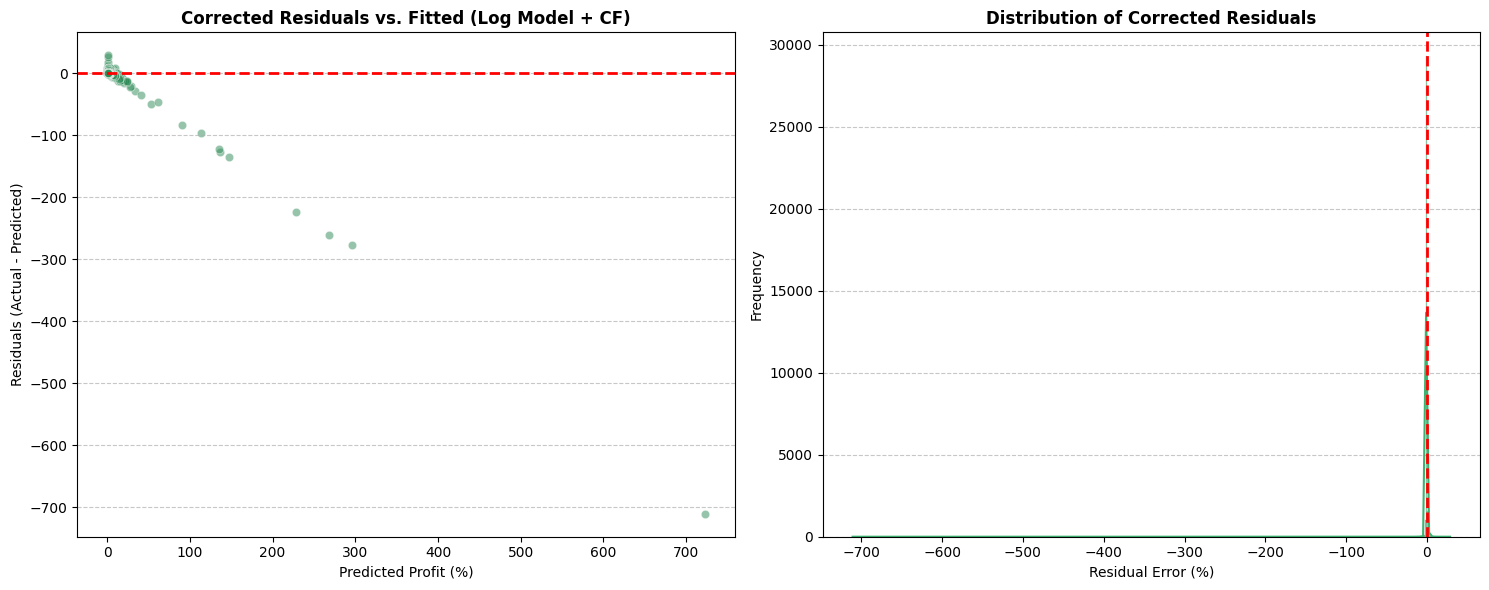

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Define targets (bounded at 0.005, capped at 10.0 to match your logic)
df_eval = df_long.copy()
df_eval['target_profit_raw'] = df_eval['total_mae']
df_eval['target_profit_log'] = np.log(df_eval['target_profit_raw'])

# 2. Drop NaNs for a clean fit
test_features = [f for f in FEATURES_COMBINED if f in df_eval.columns]
df_clean = df_eval[test_features + ['target_profit_log', 'target_profit_raw']].replace([np.inf, -np.inf], np.nan).dropna()

X_eval = df_clean[test_features].values
y_eval_log = df_clean['target_profit_log'].values
y_eval_raw = df_clean['target_profit_raw'].values

# 3. Fit LinReg in Log-Space
lin_reg = LinearRegression()
lin_reg.fit(X_eval, y_eval_log)
preds_log = lin_reg.predict(X_eval)

# 4. Duan's Smearing Estimator (The Correction)
log_residuals = y_eval_log - preds_log
duan_cf = np.mean(np.exp(log_residuals))
print(f"Duan's Correction Factor (CF): {duan_cf:.4f}")

# 5. Inverse transform predictions WITH the correction factor
preds_raw_corrected = np.exp(preds_log) * duan_cf

# 6. Calculate final residuals in raw percentage space
residuals_raw = y_eval_raw - preds_raw_corrected

# 7. Plot the Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Residuals vs. Fitted
sns.scatterplot(x=preds_raw_corrected, y=residuals_raw, alpha=0.5, ax=axes[0], color='seagreen')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Corrected Residuals vs. Fitted (Log Model + CF)', fontweight='bold')
axes[0].set_xlabel('Predicted Profit (%)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Panel B: Residual Distribution
sns.histplot(residuals_raw, bins=500, kde=True, ax=axes[1], color='mediumseagreen')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Corrected Residuals', fontweight='bold')
axes[1].set_xlabel('Residual Error (%)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# PART B: Define REG_TARGETS (Corrected Floor)
# ============================================================

# 1. Profit:
df['target_profit_log'] = df['mfe_percent']

# 2. Quality: Target B Velocity (Risk-adjusted return divided by trade lifespan)
is_long = df['signal_x'].astype(str).str.upper() == 'LONG'
df['trade_time'] = np.where(is_long,
                            (df['candles_to_max_price']).astype(float),
                            (df['candles_to_min_price']).astype(float))
df['target_quality'] = df['target_b']

# 3. Danger:
df['target_danger_log'] = (df['total_mae'])

# 4. Entry Timing: From the analytics DB table
# df['Optimum_entry']

df['target_exit_timing'] = df['trade_time']

# i have decided to just move on with the log1p transformation due to the outliers,  and am not using logs because i have values at 0 alot
#i would apply them in the cross validation step

In [75]:
# ============================================================
# TODO: Define REG_TARGETS -- your five chosen continuous target columns
# ============================================================
# Point each at an existing column, or construct new ones the way total_mae /
# class_target_bad were built last week (and if you do, add the construction
# trace Step 1 above asks for).



REG_TARGETS = {
    'profit':        'target_profit_log',
    'quality':       'target_quality',
    'danger':        'target_danger_log',
    'entry_timing':  'Optimum_entry',
    'exit_timing':   'target_exit_timing'
}

print("Targets successfully generated.")

# TODO: run Checklist Steps 2-5 below for EACH of the five, before moving to Part C.


Targets successfully generated.


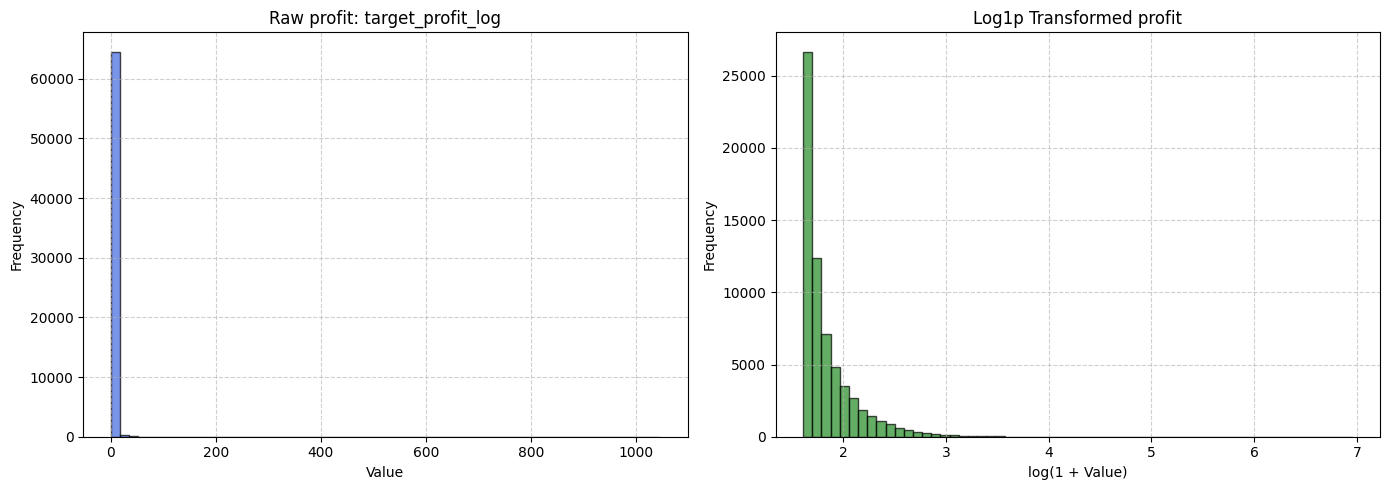

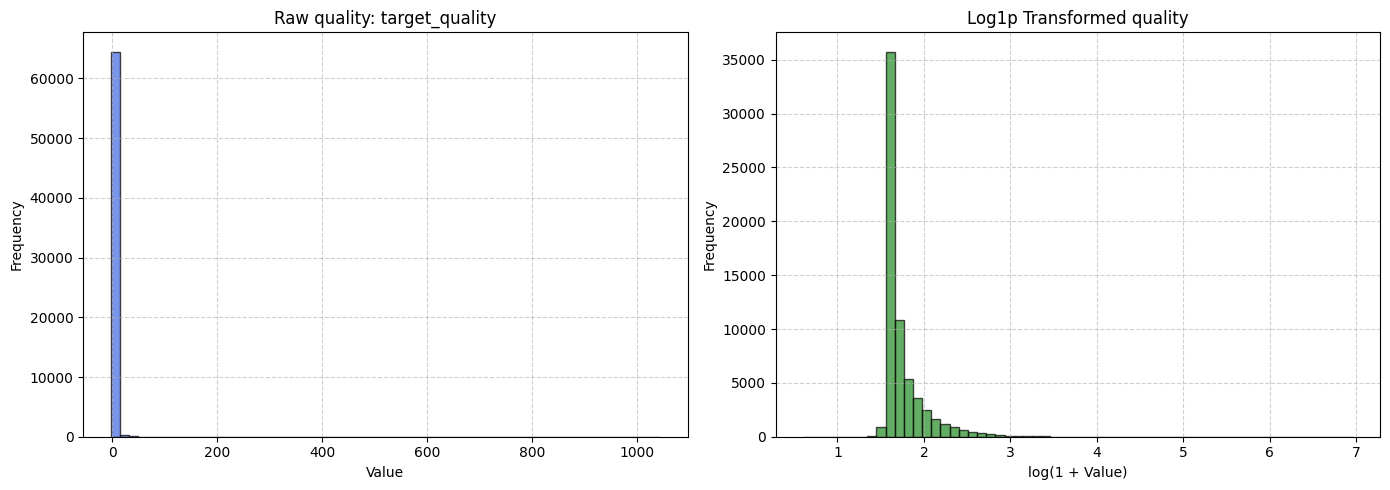

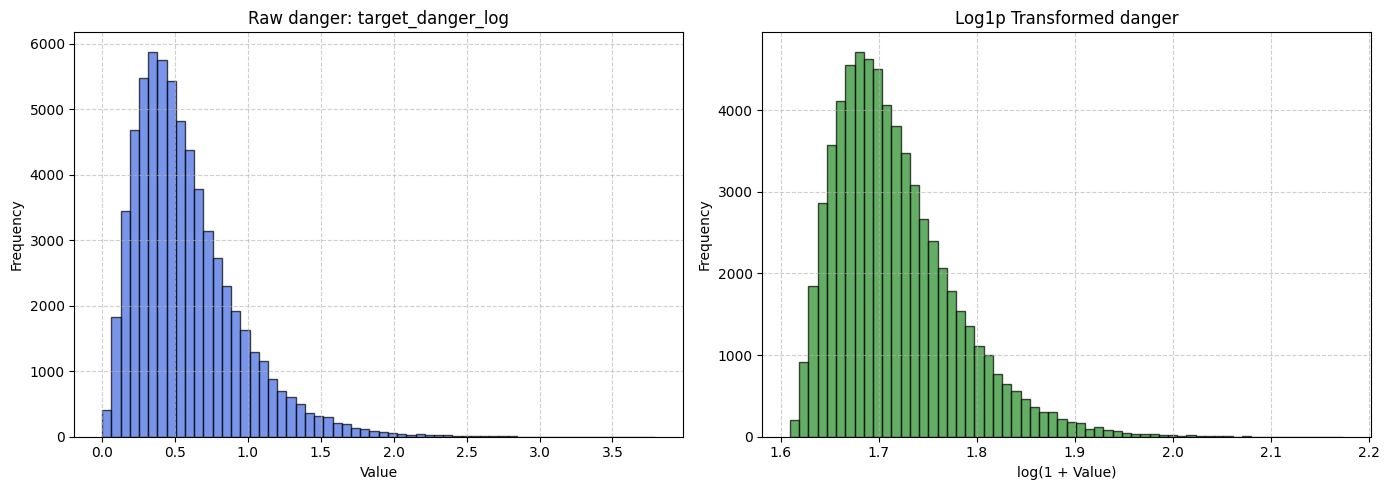

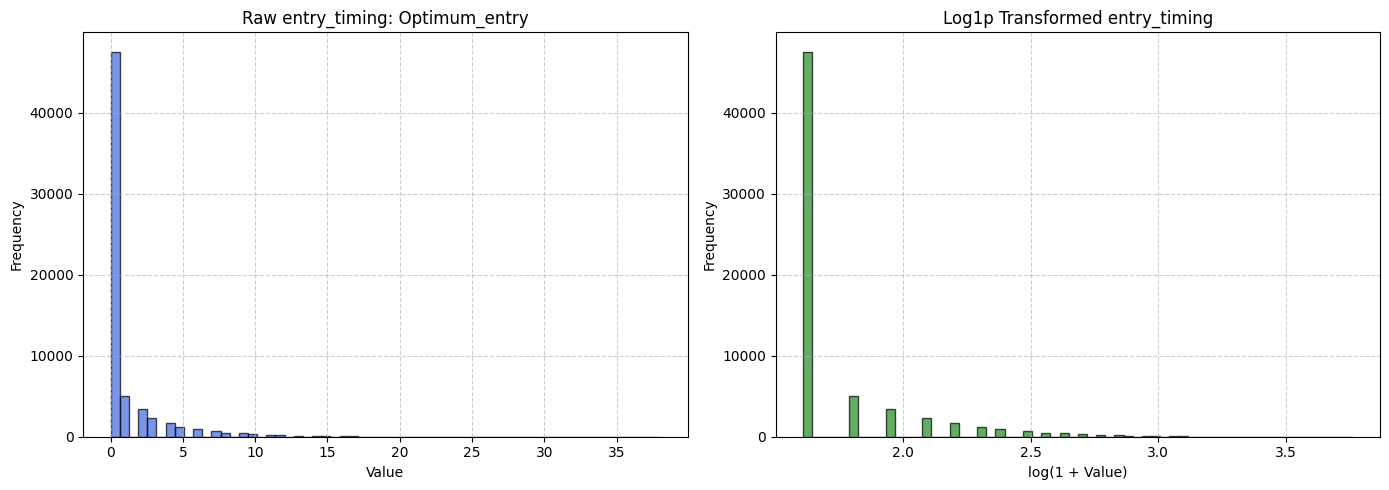

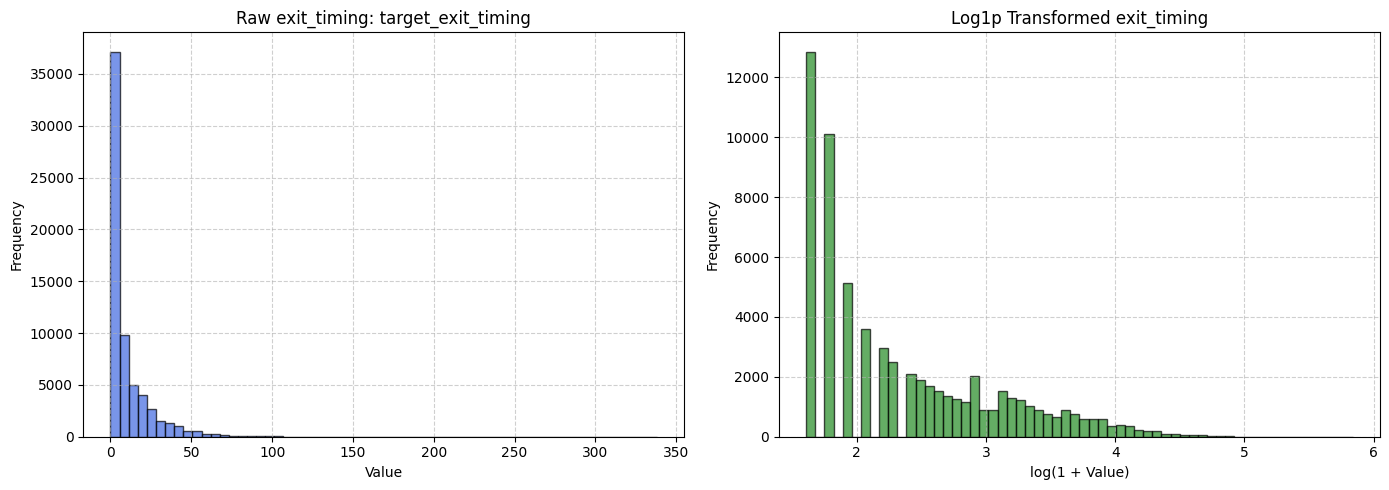

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming REG_TARGETS contains your 5 regression target column names
for name, col in REG_TARGETS.items():
    if col and col in df.columns:
        # Drop NaNs for plotting
        clean_data = df[col].dropna()

        # Create a side-by-side comparison for raw vs transformed
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # 1. Raw Distribution
        axes[0].hist(clean_data, bins=60, color='royalblue', edgecolor='k', alpha=0.7)
        axes[0].set_title(f'Raw {name}: {col}')
        axes[0].set_xlabel('Value')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # 2. Log1p Transformed Distribution
        # Using log1p safely maps 0 to 0 and compresses heavy right-skewed tails
        transformed_data = np.log(5+clean_data)
        axes[1].hist(transformed_data, bins=60, color='forestgreen', edgecolor='k', alpha=0.7)
        axes[1].set_title(f'Log1p Transformed {name}')
        axes[1].set_xlabel('log(1 + Value)')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()


In [12]:
# TODO: Step 3 -- single-feature LinearRegression checks, all five
# candidate_features = [...]  # your 3-4 best guesses, can differ per target
# for name, col in REG_TARGETS.items():
#     ...fit LinearRegression on [[f]] -> col for each candidate feature, print R² per target


In [13]:
# TODO: Step 4 -- ablation against a suspected dominant driver, for any target Step 3 flagged


In [14]:
# TODO: Step 5 -- cross-check all five REG_TARGETS against each other (correlation matrix)
#       and against class_target_1 / class_target_2 (groupby or point-biserial correlation)

# TODO: write 2-3 sentences per target (as comments) -- did each survive the checklist,
#       and do any two of the five turn out to be measuring nearly the same thing?


---
# PART C — Regression Theory + Linear Regression Benchmark (Tuesday)

### Concept

Classification metrics (accuracy, precision, AUC) don't apply here — there's no "positive class" to a continuous prediction. The equivalents:

- **MSE / RMSE** — average squared error, then square-rooted back to the target's own units for RMSE. Squaring means big misses are punished disproportionately harder than small ones — one prediction off by 5 costs as much as 25 predictions off by 1.
- **MAE** — average absolute error. Every unit of error costs the same regardless of size; more robust to outliers than MSE.
- **R²** — fraction of the target's variance your model explains, relative to just predicting the mean every time. R²=0 means "no better than guessing the average." R² can go negative on a bad enough test fold — that's not a bug, it means the model did *worse* than the mean-guess baseline on that fold.

You'll need a walk-forward CV function for regression before you can benchmark anything — same `TimeSeriesSplit` fold logic as `cv_with_scaling()`/`cv_no_scaling()` above, different metrics inside the loop.

In [15]:
# ============================================================
# TODO: Build cv_regression() -- walk-forward CV for regression models
# ============================================================
# Same skeleton as cv_with_scaling()/cv_no_scaling() in Part A.7:
#   - TimeSeriesSplit(n_splits=..., gap=...)
#   - clone the model each fold, fit on train, predict on test
#   - score with mean_squared_error (and RMSE = sqrt), mean_absolute_error, r2_score
#     instead of accuracy/precision/recall/f1/auc
#   - no need for the len(np.unique(y_tr)) < 2 check -- that was a classification-only
#     guard against a fold with only one class; doesn't apply to a continuous target
#   - decide for yourself: does this need in-fold scaling (like cv_with_scaling) for
#     LinearRegression, or can you skip it (like cv_no_scaling) once you get to the
#     tree in Part D? (Hint: think about what scaling actually changes for each model
#     type -- you answered a version of this question in Week 4.)

def cv_regression(model, df_subset, feature_cols, target_col, n_splits=5, gap=0, scale=False):
    # TODO: implement
    pass


In [16]:
# ============================================================
# TODO: Linear Regression benchmark -- loop across all five REG_TARGETS
# ============================================================
# For each (name, col) in REG_TARGETS.items(): run cv_regression() with
# LinearRegression() on df_long (FEATURES_COMBINED) and df_short, print RMSE/MAE/R².
# Store results in one dict/dataframe keyed by target name -- this is the benchmark
# table every subsequent model this week has to beat, per target.

feat_set = [f for f in FEATURES_COMBINED if f in df_long.columns]
linreg_benchmarks = {}

# TODO: for name, col in REG_TARGETS.items(): ... run cv_regression, store + print


---
# PART D — Decision Tree Regressor: Theory + Implementation (Wednesday)

### Concept

A classification tree splits to maximize Gini/entropy reduction; a regression tree splits to maximize **variance reduction** — at each candidate split, it asks "does dividing these rows into two groups make each group's target values more tightly clustered around their own group mean?" A leaf's prediction is just the mean of the training targets that landed in it, not a majority vote.

Same bias-variance shape you saw in Week 4, different y-axis: shallow trees underfit (high bias, both train and CV RMSE are bad and close together), deep trees overfit (train RMSE keeps dropping, CV RMSE stops improving or gets worse, gap widens).

In [17]:
# ============================================================
# TODO: DecisionTreeRegressor vs LinReg benchmark -- all five REG_TARGETS
# ============================================================
# For each (name, col) in REG_TARGETS.items(): fit DecisionTreeRegressor
# (default params + random_state=42) via cv_regression() on df_long / feat_set / col.
# Compare RMSE/MAE/R² directly against that target's LinReg benchmark from Part C.

tree_results = {}
# TODO: loop, fit + evaluate, store in tree_results


In [18]:
# ============================================================
# TODO: Bias-variance curve, depths 1-20, for at least 2 of the 5 targets
# ============================================================
# Pick the 2 targets where LinReg over/underperformed most in Part C. For each:
# for max_depth in range(1, 21): fit DecisionTreeRegressor(max_depth=d), record
# BOTH train RMSE and CV RMSE (via cv_regression). Plot both curves, x=depth, y=RMSE.
# Same read as Week 4: where do the curves diverge, where does CV RMSE flatten?

# TODO: sweep + plot, chosen targets


---
# PART E — Pruning + Regression-Specific Diagnostics (Thursday)

### Concept

Cost-complexity pruning works the same way it did in Week 4 — `cost_complexity_pruning_path()` gives you a sequence of `ccp_alpha` values, each corresponding to a differently-pruned tree, walk-forward CV picks the best one. The diagnostics that follow are new: a regression model's errors have a *sign and a shape*, not just a right/wrong label, and that shape often tells you something a single RMSE number can't.

In [19]:
# ============================================================
# TODO: Cost-complexity pruning path -- per target
# ============================================================
# For each of the 5: path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
# Sweep ccp_alphas from that path, cv_regression() each one, pick the best by CV RMSE.
# Lock in BEST_TREE_PARAMS per target (a dict of dicts).

BEST_TREE_PARAMS = {}
# TODO: loop over REG_TARGETS, prune, store best params per target


In [20]:
# ============================================================
# TODO: Residual diagnostics -- pick at least 2 of the 5 targets to go deep on
# ============================================================
# For each chosen target: fit its best tree, predict on a held-out walk-forward
# test fold.
# 1. Scatter: predicted (x) vs actual (y), with a y=x reference line.
# 2. Scatter: residuals (actual - predicted) vs each of your top 3-4 features for
#    that target -- visible structure (slope, curve, fan shape) means the model
#    is still missing something systematic.

# TODO: predicted vs actual plots
# TODO: residuals vs top features plots


In [21]:
# ============================================================
# TODO: Where does each tree fail worst?
# ============================================================
# For each of the 5: sort by |residual| descending, inspect the top 15-20 rows
# directly. Pattern (symbol/session/regime) or unstructured noise?

# TODO: build residuals dataframe per target, sort, inspect top rows


---
# PART F — Consolidation + Week 5 Honest Record (Friday)

In [22]:
# ============================================================
# TODO: Final comparison -- LinReg benchmark vs tuned tree, all 5 targets, both directions
# ============================================================
# TODO: build one table: {Target, Model: LinReg/Tuned Tree, Direction: LONG/SHORT,
#       RMSE, MAE, R²} across all five REG_TARGETS and print it


In [23]:
# ============================================================
# TODO: Week 5 Honest Record
# ============================================================
week5_record = """
=================================================================
        WEEK 5 PRODUCTION LOG — REGRESSION TREES (5 TARGETS)
=================================================================

  TARGETS DEFINED
    1. Profit       -- column: TODO | rejected alternative: TODO
    2. Quality       -- column: TODO | rejected alternative: TODO
    3. Danger        -- total_mae, threshold 1.0 | re-validation vs 0.5 threshold: TODO
    4. Entry timing  -- Optimum_entry | fresh correlation check vs #1/#2: TODO
    5. Exit timing   -- column: TODO | labeler-consistency check with Target 4: TODO

  CROSS-TARGET CHECK
    Correlation matrix across all 5 + class_target_1/2: TODO
    Any two targets measuring nearly the same thing?: TODO

  MODEL RESULTS (RMSE / MAE / R², LONG then SHORT, LinReg -> Tuned Tree)
    Profit:       TODO
    Quality:      TODO
    Danger:       TODO
    Entry timing: TODO
    Exit timing:  TODO

  DIAGNOSTICS
    Easiest target to predict, and why: TODO
    Hardest target to predict, and why: TODO
    Worst-failure pattern(s) found: TODO

  HONEST VERDICT
    Biggest surprise this week: TODO
    Which of the 5 (if any) would you actually use in production, and how: TODO
    Expectation for Week 6 Random Forest: TODO
=================================================================
"""
print(week5_record)


        WEEK 5 PRODUCTION LOG — REGRESSION TREES (5 TARGETS)

  TARGETS DEFINED
    1. Profit       -- column: TODO | rejected alternative: TODO
    2. Quality       -- column: TODO | rejected alternative: TODO
    3. Danger        -- total_mae, threshold 1.0 | re-validation vs 0.5 threshold: TODO
    4. Entry timing  -- Optimum_entry | fresh correlation check vs #1/#2: TODO
    5. Exit timing   -- column: TODO | labeler-consistency check with Target 4: TODO

  CROSS-TARGET CHECK
    Correlation matrix across all 5 + class_target_1/2: TODO
    Any two targets measuring nearly the same thing?: TODO

  MODEL RESULTS (RMSE / MAE / R², LONG then SHORT, LinReg -> Tuned Tree)
    Profit:       TODO
    Quality:      TODO
    Danger:       TODO
    Entry timing: TODO
    Exit timing:  TODO

  DIAGNOSTICS
    Easiest target to predict, and why: TODO
    Hardest target to predict, and why: TODO
    Worst-failure pattern(s) found: TODO

  HONEST VERDICT
    Biggest surprise this week: TODO
    